In [6]:
!pip install -q diffusers transformers accelerate safetensors torch huggingface_hub

In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [8]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
import os

output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

prompts = [
    "A futuristic city at sunset, ultra realistic",
    "A cute robot reading a book, digital art",
    "A mountain landscape with river, cinematic lighting",
    "An astronaut walking on Mars, realistic",
    "A fantasy castle in the clouds",
    "A cyberpunk street at night, neon lights",
    "A tiger in the jungle, wildlife photography",
    "A peaceful village in India, watercolor style",
    "A space nebula with stars, high detail",
    "A medieval warrior portrait, dramatic lighting"
]

for i, prompt in enumerate(prompts):
    image = pipe(prompt, guidance_scale=7.5).images[0]
    image.save(f"{output_dir}/image_{i+1}.png")
    print(f"Saved image_{i+1}.png")


  0%|          | 0/50 [00:00<?, ?it/s]

Saved image_1.png


  0%|          | 0/50 [00:00<?, ?it/s]

Saved image_2.png


  0%|          | 0/50 [00:00<?, ?it/s]

...

Saved image_8.png


  0%|          | 0/50 [00:00<?, ?it/s]

Saved image_9.png


  0%|          | 0/50 [00:00<?, ?it/s]

Saved image_10.png


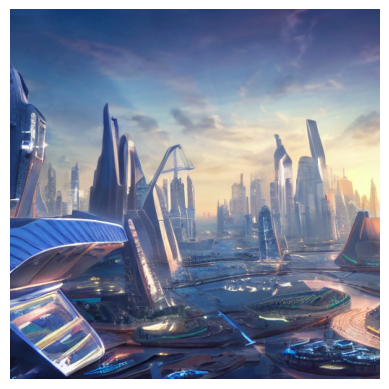

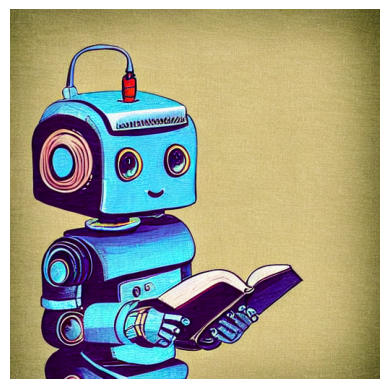

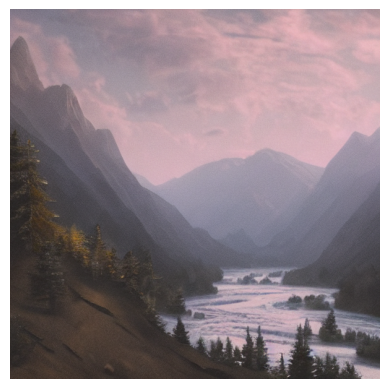

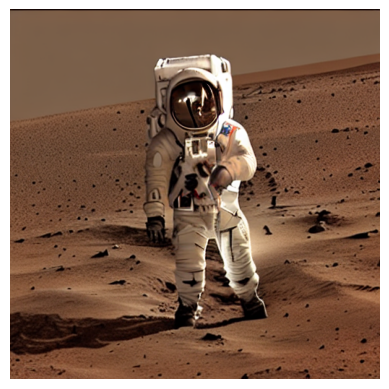

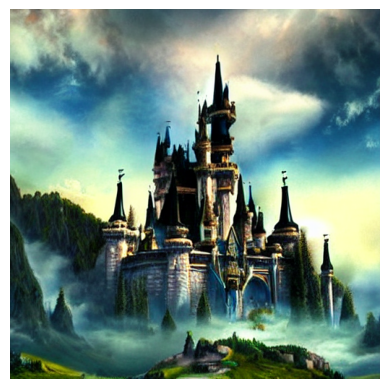

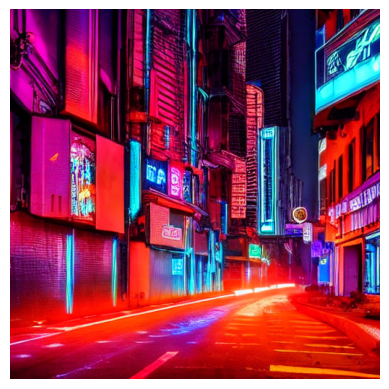

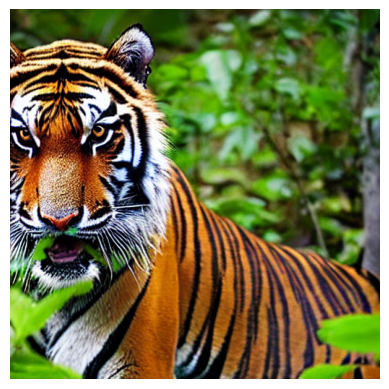

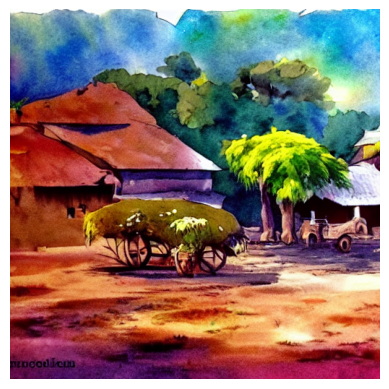

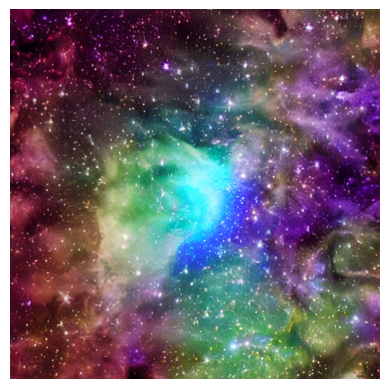

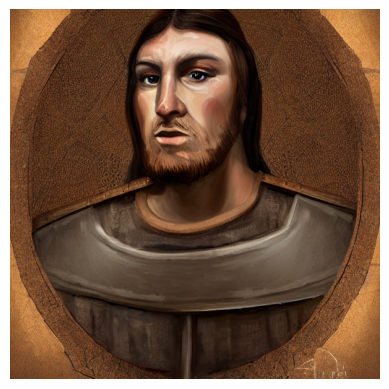

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(1, 11):
    img = Image.open(f"generated_images/image_{i}.png")
    plt.imshow(img)
    plt.axis("off")
    plt.show()